В этом ноутбуке попробую ряд экспериментов над выдачей постов. В целом, у нас уже есть эксперименты по векторизациям, применением DL в контексте классификации и с дальнейшей кластеризацией. Моя идея в том, чтобы после классификации выделять основные релевантные посты не с помощью кластеризации, а путём ранжирования. Это похоже на слой рексистемы, но не в смысле коллаборативной фильтрации, а в смысле контентных рекомендаций, то есть предлагаем пост на основе новизны, источника, похожести (задача ранжирования).

classification → scoring → ranking → grouping → summary

## План ноутбука

1. Подготовить данные и определить пул кандидатов.
2. Собрать признаки для ранжирования.
3. Обучить базовые модели scoring и ranking.
4. Обучить DL baseline: сначала RNN, затем Transformer.
5. Сравнить модели по ranking-метрикам.
6. Показать, как результат встроится в сервис и выдачу бота.

In [61]:
from pathlib import Path
import sys
import re
import math
from collections import Counter

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()

root = cwd if (cwd / 'aggregate_bot_modules').exists() else cwd.parent

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

pd.set_option('display.max_colwidth', 120)
root

WindowsPath('D:/studying/aggregation-bot/aggregator-bot')

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

raw_data_dir = root / 'data' / 'raw'
processed_data_path = root / 'ML' / 'raw_posts_labeled.csv'
raw_data_dir, processed_data_path

(WindowsPath('D:/studying/aggregation-bot/aggregator-bot/data/raw'),
 WindowsPath('D:/studying/aggregation-bot/aggregator-bot/ML/raw_posts_labeled.csv'))

### Импорты и настройки

Ниже подключаем базовые библиотеки и настраиваем пути проекта.

## 1. Данные и кандидаты

Сначала определяем, какие посты вообще попадают в пул ранжирования. Для проекта это могут быть посты за день, сообщения из выбранных каналов или тексты, уже прошедшие базовый тематический фильтр.

In [63]:
def load_candidate_data():
    raw_files = sorted(raw_data_dir.glob('*csv')) if raw_data_dir.exists() else []
    parts = []
    for path in raw_files:
        part = pd.read_csv(path)
        if {'text', 'topic'}.issubset(part.columns):
            parts.append(part)

    if parts:
        df = pd.concat(parts, ignore_index=True)
        source = f'data/raw/*.csv ({len(parts)} files)'
    elif processed_data_path.exists():
        df = pd.read_csv(processed_data_path)
        source = 'ML/raw_posts_labeled.csv'
    else:
        df = pd.DataFrame(columns=['text', 'topic'])
        source = 'empty'

    df = df.dropna(subset=['text', 'topic']).copy()
    df['text'] = df['text'].astype(str)
    df['topic'] = df['topic'].astype(str)
    df['text_clean'] = df['text'].str.lower().str.replace(r'http\S+|www\.\S+|t\.me/\S+', ' ', regex=True)
    df['text_clean'] = df['text_clean'].str.replace(r'@\w+|#\w+', ' ', regex=True)
    df['text_clean'] = df['text_clean'].str.replace(r'[^a-zA-Zа-яА-ЯёЁ\s]', ' ', regex=True)
    df['text_clean'] = df['text_clean'].str.replace(r'\s+', ' ', regex=True).str.strip()
    df = df[df['text_clean'].str.len() >= 15].reset_index(drop=True)
    return df, source

df, source = load_candidate_data()
print('Source:', source)
print('Shape:', df.shape)
df.head()

Source: data/raw/*.csv (13 files)
Shape: (11041, 9)


,id,date,text,views,forwards,replies,channel,topic,text_clean
0,88505,2025-12-01T09:27:37+00:00,"**Суд в Иркутске вынес приговор бывшим руководителям СИЗО в Иркутске, где пытали заключенных\n**\nПо обвинению в пре...",6624.0,21.0,NaN,@bbcrussian,politics,суд в иркутске вынес приговор бывшим руководителям сизо в иркутске где пытали заключенных по обвинению в превышении ...
1,88504,2025-12-01T08:42:23+00:00,**В Сумской области при атаке дрона погиб мужчина\n**\nВ Белопольской общине в Сумской области российский дрон попал...,17834.0,1.0,NaN,@bbcrussian,politics,в сумской области при атаке дрона погиб мужчина в белопольской общине в сумской области российский дрон попал в авто...
2,88503,2025-12-01T08:29:28+00:00,**В России подорожал утильсбор\n**\nНовые правила расчета утилизационного сбора вступили в силу в России с 1 декабря...,20466.0,67.0,NaN,@bbcrussian,politics,в россии подорожал утильсбор новые правила расчета утилизационного сбора вступили в силу в россии с декабря теперь е...
3,88502,2025-12-01T08:01:31+00:00,**Рэпера Face будут заочно судить в России по статье для «иноагентов»\n**\nВ Кировский суд Уфы поступило уголовное д...,25236.0,31.0,NaN,@bbcrussian,politics,рэпера face будут заочно судить в россии по статье для иноагентов в кировский суд уфы поступило уголовное дело возбу...
4,88501,2025-12-01T07:37:21+00:00,"**CNN: Украину не будут принуждать отказаться от вступления в НАТО, запрет могут согласовать между собой Россия, США...",30950.0,72.0,NaN,@bbcrussian,politics,cnn украину не будут принуждать отказаться от вступления в нато запрет могут согласовать между собой россия сша и ал...


In [64]:
candidate_cols = ['id', 'date', 'text', 'text_clean', 'views', 'forwards', 'replies', 'channel', 'channel_short', 'topic']
available_cols = [col for col in candidate_cols if col in df.columns]
missing_cols = [col for col in candidate_cols if col not in df.columns]

print('available columns:', available_cols)
print('missing columns:', missing_cols)

meta_df = df[available_cols].copy()

if 'date' in meta_df.columns:
    meta_df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
    meta_df['age_in_hours'] = (meta_df['date'].max() - meta_df['date']).dt.total_seconds() / 3600
    meta_df['age_in_hours'] = meta_df['age_in_hours'].clip(lower=0)
    meta_df['age_in_hours_log'] = np.log1p(meta_df['age_in_hours'])

meta_df.head()

available columns: ['id', 'date', 'text', 'text_clean', 'views', 'forwards', 'replies', 'channel', 'topic']
missing columns: ['channel_short']


,id,date,text,text_clean,views,forwards,replies,channel,topic,age_in_hours,age_in_hours_log
0,88505,2025-12-01 09:27:37+00:00,"**Суд в Иркутске вынес приговор бывшим руководителям СИЗО в Иркутске, где пытали заключенных\n**\nПо обвинению в пре...",суд в иркутске вынес приговор бывшим руководителям сизо в иркутске где пытали заключенных по обвинению в превышении ...,6624.0,21.0,NaN,@bbcrussian,politics,0.136667,0.128100
1,88504,2025-12-01 08:42:23+00:00,**В Сумской области при атаке дрона погиб мужчина\n**\nВ Белопольской общине в Сумской области российский дрон попал...,в сумской области при атаке дрона погиб мужчина в белопольской общине в сумской области российский дрон попал в авто...,17834.0,1.0,NaN,@bbcrussian,politics,0.890556,0.636871
2,88503,2025-12-01 08:29:28+00:00,**В России подорожал утильсбор\n**\nНовые правила расчета утилизационного сбора вступили в силу в России с 1 декабря...,в россии подорожал утильсбор новые правила расчета утилизационного сбора вступили в силу в россии с декабря теперь е...,20466.0,67.0,NaN,@bbcrussian,politics,1.105833,0.744711
3,88502,2025-12-01 08:01:31+00:00,**Рэпера Face будут заочно судить в России по статье для «иноагентов»\n**\nВ Кировский суд Уфы поступило уголовное д...,рэпера face будут заочно судить в россии по статье для иноагентов в кировский суд уфы поступило уголовное дело возбу...,25236.0,31.0,NaN,@bbcrussian,politics,1.571667,0.944554
4,88501,2025-12-01 07:37:21+00:00,"**CNN: Украину не будут принуждать отказаться от вступления в НАТО, запрет могут согласовать между собой Россия, США...",cnn украину не будут принуждать отказаться от вступления в нато запрет могут согласовать между собой россия сша и ал...,30950.0,72.0,NaN,@bbcrussian,politics,1.974444,1.090057


In [65]:
meta_df.isna().sum()

id                     0
date                   0
text                   0
text_clean             0
views                540
forwards             540
replies             6388
channel                0
topic                  0
age_in_hours           0
age_in_hours_log       0
dtype: int64

In [66]:
has_nul = ['views', 'forwards', 'replies']
for col in has_nul:
    meta_df[col] = meta_df[col].fillna(meta_df[col].median())

In [67]:
diap = ['views', 'forwards', 'replies']
for col in diap:
    print("Данные по", col)
    print(f'{meta_df[col].describe()}\n')

Данные по views
count     11041.000000
mean     107920.072548
std      149017.733086
min         306.000000
25%       17872.000000
50%       61115.000000
75%      130282.000000
max      838795.000000
Name: views, dtype: float64

Данные по forwards
count    11041.000000
mean       192.618060
std        435.309236
min          0.000000
25%         31.000000
50%         80.000000
75%        192.000000
max      13343.000000
Name: forwards, dtype: float64

Данные по replies
count    11041.000000
mean         5.053618
std         19.837305
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max       1273.000000
Name: replies, dtype: float64



In [68]:
for c in diap:
    meta_df[c] = np.log1p(meta_df[c])

In [69]:
views_norm = (meta_df['views'] - meta_df['views'].min()) / (meta_df['views'].max() - meta_df['views'].min() + 1e-6)
forwards_norm = (meta_df['forwards'] - meta_df['forwards'].min()) / (meta_df['forwards'].max() - meta_df['forwards'].min() + 1e-6)
replies_norm = (meta_df['replies'] - meta_df['replies'].min()) / (meta_df['replies'].max() - meta_df['replies'].min() + 1e-6)

meta_df['target_score_v1'] = 0.5 * views_norm + 0.3 * forwards_norm + 0.2 * replies_norm
meta_df['target_score_v2'] = 0.45 * meta_df['views'] + 0.25 * meta_df['forwards'] + 0.30 * meta_df['replies']

decay_factor = np.exp(-meta_df['age_in_hours'] / (24 * 7))
meta_df['target_score_v3'] = decay_factor * (0.5 * meta_df['views'] + 0.3 * meta_df['forwards'] + 0.2 * meta_df['replies'])

meta_df['target_score'] = meta_df['target_score_v1']

print("Сравнение трёх вариантов target_score:")

print("\nВариант 1 (нормализованный, базовый):")
print(meta_df['target_score_v1'].describe())
print("\nВариант 2 (изменённые веса: replies +10%):")
print(meta_df['target_score_v2'].describe())
print("\nВариант 3 (с time decay за неделю):")
print(meta_df['target_score_v3'].describe())
print("\nВыбран для обучения: Вариант 1")

meta_df.head()

Сравнение трёх вариантов target_score:

Вариант 1 (нормализованный, базовый):
count    11041.000000
mean         0.474327
std          0.140982
min          0.061457
25%          0.392164
50%          0.482256
75%          0.580482
max          0.828631
Name: target_score_v1, dtype: float64

Вариант 2 (изменённые веса: replies +10%):
count    11041.000000
mean         6.158313
std          1.073904
min          3.063559
25%          5.534254
50%          6.232233
75%          6.956699
max          9.400551
Name: target_score_v2, dtype: float64

Вариант 3 (с time decay за неделю):
count    1.104100e+04
mean     1.829085e+00
std      1.982292e+00
min      3.288809e-87
25%      1.628484e-02
50%      1.195837e+00
75%      3.125877e+00
max      8.742296e+00
Name: target_score_v3, dtype: float64

Выбран для обучения: Вариант 1


,id,date,text,text_clean,views,forwards,replies,channel,topic,age_in_hours,age_in_hours_log,target_score_v1,target_score_v2,target_score_v3,target_score
0,88505,2025-12-01 09:27:37+00:00,"**Суд в Иркутске вынес приговор бывшим руководителям СИЗО в Иркутске, где пытали заключенных\n**\nПо обвинению в пре...",суд в иркутске вынес приговор бывшим руководителям сизо в иркутске где пытали заключенных по обвинению в превышении ...,8.798606,3.091042,0.693147,@bbcrussian,politics,0.136667,0.128100,0.311112,4.940077,5.460801,0.311112
1,88504,2025-12-01 08:42:23+00:00,**В Сумской области при атаке дрона погиб мужчина\n**\nВ Белопольской общине в Сумской области российский дрон попал...,в сумской области при атаке дрона погиб мужчина в белопольской общине в сумской области российский дрон попал в авто...,9.788918,0.693147,0.693147,@bbcrussian,politics,0.890556,0.636871,0.297955,4.786244,5.213324,0.297955
2,88503,2025-12-01 08:29:28+00:00,**В России подорожал утильсбор\n**\nНовые правила расчета утилизационного сбора вступили в силу в России с 1 декабря...,в россии подорожал утильсбор новые правила расчета утилизационного сбора вступили в силу в россии с декабря теперь е...,9.926569,4.219508,0.693147,@bbcrussian,politics,1.105833,0.744711,0.418026,5.729777,6.325989,0.418026
3,88502,2025-12-01 08:01:31+00:00,**Рэпера Face будут заочно судить в России по статье для «иноагентов»\n**\nВ Кировский суд Уфы поступило уголовное д...,рэпера face будут заочно судить в россии по статье для иноагентов в кировский суд уфы поступило уголовное дело возбу...,10.136066,3.465736,0.693147,@bbcrussian,politics,1.571667,0.944554,0.407457,5.635608,6.188220,0.407457
4,88501,2025-12-01 07:37:21+00:00,"**CNN: Украину не будут принуждать отказаться от вступления в НАТО, запрет могут согласовать между собой Россия, США...",cnn украину не будут принуждать отказаться от вступления в нато запрет могут согласовать между собой россия сша и ал...,10.340161,4.290459,0.693147,@bbcrussian,politics,1.974444,1.090057,0.446401,5.933631,6.518783,0.446401


<Axes: >

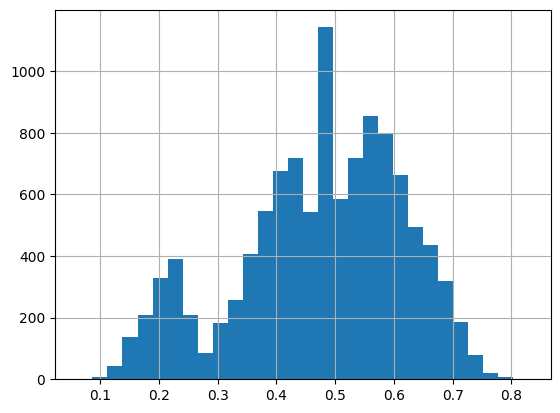

In [70]:
meta_df['target_score'].hist(bins=30)

сборка данных для обучения, сплит по времени. для конструрования фичей будут использоваться метаданные, статистики текста

In [71]:
work_df = meta_df.copy()

if 'date' in work_df.columns:
    work_df = work_df.sort_values('date').reset_index(drop=True)
    split_idx = int(len(work_df) * 0.8)
    train_df = work_df.iloc[:split_idx].copy()
    val_df = work_df.iloc[split_idx:].copy()
else:
    train_df, val_df = train_test_split(work_df, test_size=0.2, random_state=42)

print('train shape:', train_df.shape)
print('val shape:', val_df.shape)

feature_cols = [col for col in ['views', 'forwards', 'replies', 'age_in_hours', 'age_in_hours_log'] if col in work_df.columns]
print('feature columns:', feature_cols)

train_df[feature_cols].head()

train shape: (8832, 15)
val shape: (2209, 15)
feature columns: ['views', 'forwards', 'replies', 'age_in_hours', 'age_in_hours_log']


,views,forwards,replies,age_in_hours,age_in_hours_log
0,11.020529,4.394449,0.693147,33780.700000,10.427675
1,11.020529,4.394449,0.693147,33766.785833,10.427263
2,11.020529,4.394449,0.693147,33766.724444,10.427261
3,11.020529,4.394449,0.000000,33766.717778,10.427261
4,11.020529,4.394449,0.693147,33766.703333,10.427260


In [72]:
numeric_features = [col for col in ['age_in_hours_log'] if col in train_df.columns]
text_col = 'text_clean' if 'text_clean' in train_df.columns else 'text'

for frame in [train_df, val_df]:
    frame['text_length'] = frame['text'].fillna('').astype(str).str.len()
    frame['word_count'] = frame['text'].fillna('').astype(str).str.split().apply(len)
    
    frame['url_count'] = frame['text'].fillna('').astype(str).str.count(r'http\S+|www\.\S+|t\.me/\S+')
    frame['mention_count'] = frame['text'].fillna('').astype(str).str.count(r'@\w+')
    frame['hashtag_count'] = frame['text'].fillna('').astype(str).str.count(r'#\w+')
    
    frame['has_url'] = (frame['url_count'] > 0).astype(int)
    frame['has_mention'] = (frame['mention_count'] > 0).astype(int)
    frame['has_hashtag'] = (frame['hashtag_count'] > 0).astype(int)
    
    frame['unique_word_ratio'] = frame['text_clean'].apply(
        lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0
    )
    frame['avg_word_length'] = frame['text_clean'].apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
    )
    
    frame['has_numbers'] = frame['text'].fillna('').astype(str).str.contains(r'\d', regex=True).astype(int)
    frame['exclamation_count'] = frame['text'].fillna('').astype(str).str.count(r'!')
    frame['question_count'] = frame['text'].fillna('').astype(str).str.count(r'\?')
    frame['punctuation_density'] = frame['text'].fillna('').astype(str).str.count(r'[!?.,;:-]') / (frame['text_length'] + 1)

extra_text_features = [
    'text_length', 'word_count', 
    'url_count', 'mention_count', 'hashtag_count',
    'has_url', 'has_mention', 'has_hashtag',
    'unique_word_ratio', 'avg_word_length',
    'has_numbers', 'exclamation_count', 'question_count', 'punctuation_density'
]
feature_cols = numeric_features + extra_text_features

X_train = train_df[feature_cols].copy()
y_train = train_df['target_score'].copy()
X_val = val_df[feature_cols].copy()
y_val = val_df['target_score'].copy()

print('feature columns:', feature_cols)
print('X_train shape:', X_train.shape)
print('X_val shape:', X_val.shape)
print(f'\nВсего признаков: {len(feature_cols)}')

X_train.head()

feature columns: ['age_in_hours_log', 'text_length', 'word_count', 'url_count', 'mention_count', 'hashtag_count', 'has_url', 'has_mention', 'has_hashtag', 'unique_word_ratio', 'avg_word_length', 'has_numbers', 'exclamation_count', 'question_count', 'punctuation_density']
X_train shape: (8832, 15)
X_val shape: (2209, 15)

Всего признаков: 15


,age_in_hours_log,text_length,word_count,url_count,mention_count,hashtag_count,has_url,has_mention,has_hashtag,unique_word_ratio,avg_word_length,has_numbers,exclamation_count,question_count,punctuation_density
0,10.427675,15,2,0,0,0,0,0,0,1.0,7.000000,0,0,0,0.000000
1,10.427263,28,4,0,0,0,0,0,0,1.0,6.250000,0,0,0,0.000000
2,10.427261,28,5,0,0,0,0,0,0,1.0,4.800000,0,0,0,0.000000
3,10.427261,36,5,0,0,0,0,0,0,1.0,5.166667,0,0,0,0.027027
4,10.427260,62,8,0,0,0,0,0,0,1.0,6.625000,0,0,1,0.031746


In [74]:
def dcg_at_k(y_true, k=10):
    """Discounted Cumulative Gain: сумма релевантности с дисконтом по позиции"""
    dcg = 0.0
    for i in range(min(k, len(y_true))):
        dcg += y_true[i] / np.log2(i + 2) 
    return dcg

def ndcg_at_k(y_true, y_pred, k=10):
    """Normalized DCG: ratio реального DCG к идеальному (отсортированные true labels)"""
    ideal_order = np.argsort(-y_true)[:k]
    ideal_dcg = dcg_at_k(y_true[ideal_order], k=k)
    
    if ideal_dcg == 0:
        return 0.0
    
    pred_order = np.argsort(-y_pred)[:k]
    pred_dcg = dcg_at_k(y_true[pred_order], k=k)
    
    return pred_dcg / ideal_dcg

def mrr_score(y_true, y_pred):
    """Mean Reciprocal Rank: позиция первого релевантного документа (score > median)"""
    threshold = np.median(y_true)
    pred_order = np.argsort(-y_pred)
    
    for i, idx in enumerate(pred_order):
        if y_true[idx] > threshold:
            return 1.0 / (i + 1)
    return 0.0

def precision_at_k(y_true, y_pred, k=10):
    """Precision@k: доля релевантных документов в топ-k"""
    threshold = np.median(y_true)
    pred_order = np.argsort(-y_pred)[:k]
    relevant = np.sum(y_true[pred_order] > threshold)
    return relevant / k if k > 0 else 0.0

y_true_test = np.array([5.0, 3.0, 1.0, 4.0, 2.0])
y_pred_test = np.array([4.9, 3.1, 1.2, 3.9, 2.1])

print("Тестирование метрик ранжирования:")
print(f"nDCG@3: {ndcg_at_k(y_true_test, y_pred_test, k=3):.4f}")
print(f"MRR: {mrr_score(y_true_test, y_pred_test):.4f}")
print(f"Precision@3: {precision_at_k(y_true_test, y_pred_test, k=3):.4f}")

Тестирование метрик ранжирования:
nDCG@3: 1.0000
MRR: 1.0000
Precision@3: 0.6667


In [75]:
y_val_array = y_val.values
X_val_array = X_val.values

rule_score = (
    -0.3 * X_val[['age_in_hours_log']].values.flatten() + 
    0.4 * X_val[['unique_word_ratio']].values.flatten() + 
    0.2 * X_val[['has_numbers']].values.flatten() +      
    0.1 * X_val[['word_count']].values.flatten() / 100     
)

rule_score = (rule_score - rule_score.min()) / (rule_score.max() - rule_score.min() + 1e-6)

# Оцениваем на валидации
ndcg_rule = ndcg_at_k(y_val_array, rule_score, k=10)
mrr_rule = mrr_score(y_val_array, rule_score)
prec_rule = precision_at_k(y_val_array, rule_score, k=10)

print("RULE-BASED BASELINE (эмпирические веса)")
print(f"nDCG@10:      {ndcg_rule:.4f}")
print(f"MRR:          {mrr_rule:.4f}")
print(f"Precision@10: {prec_rule:.4f}")

RULE-BASED BASELINE (эмпирические веса)
nDCG@10:      0.4000
MRR:          0.0417
Precision@10: 0.0000


In [95]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_val_scaled)

y_pred_ridge_norm = (y_pred_ridge - y_pred_ridge.min()) / (y_pred_ridge.max() - y_pred_ridge.min() + 1e-6)

ndcg_ridge = ndcg_at_k(y_val_array, y_pred_ridge_norm, k=10)
mrr_ridge = mrr_score(y_val_array, y_pred_ridge_norm)
prec_ridge = precision_at_k(y_val_array, y_pred_ridge_norm, k=10)

print("RIDGE REGRESSION BASELINE")
print(f"nDCG@10:      {ndcg_ridge:.4f}")
print(f"MRR:          {mrr_ridge:.4f}")
print(f"Precision@10: {prec_ridge:.4f}")

RIDGE REGRESSION BASELINE
nDCG@10:      0.5891
MRR:          0.5000
Precision@10: 0.2000


In [84]:
import xgboost as xgb
xgb_available = True

if xgb_available:
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='rmse'
    )

    xgb_model.fit(X_train_scaled, y_train, verbose=False)
    
    y_pred_xgb = xgb_model.predict(X_val_scaled)
    y_pred_xgb_norm = (y_pred_xgb - y_pred_xgb.min()) / (y_pred_xgb.max() - y_pred_xgb.min() + 1e-6)
    
    ndcg_xgb = ndcg_at_k(y_val_array, y_pred_xgb_norm, k=10)
    mrr_xgb = mrr_score(y_val_array, y_pred_xgb_norm)
    prec_xgb = precision_at_k(y_val_array, y_pred_xgb_norm, k=10)
    
    print("XGBOOST BASELINE (Gradient Boosting)")
    print(f"nDCG@10:      {ndcg_xgb:.4f}")
    print(f"MRR:          {mrr_xgb:.4f}")
    print(f"Precision@10: {prec_xgb:.4f}")
    
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(feature_importance.head(10).to_string(index=False))

XGBOOST BASELINE (Gradient Boosting)
nDCG@10:      0.8709
MRR:          1.0000
Precision@10: 1.0000
            Feature  Importance
   age_in_hours_log    0.172238
            has_url    0.165911
          url_count    0.133158
      mention_count    0.116044
        has_mention    0.091148
      hashtag_count    0.080867
        has_hashtag    0.041786
         word_count    0.035740
     question_count    0.033438
punctuation_density    0.032284


C:\Users\sinte\AppData\Local\Temp\ipykernel_39348\2455900188.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=15, ha='right')
C:\Users\sinte\AppData\Local\Temp\ipykernel_39348\2455900188.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=15, ha='right')
C:\Users\sinte\AppData\Local\Temp\ipykernel_39348\2455900188.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=15, ha='right')


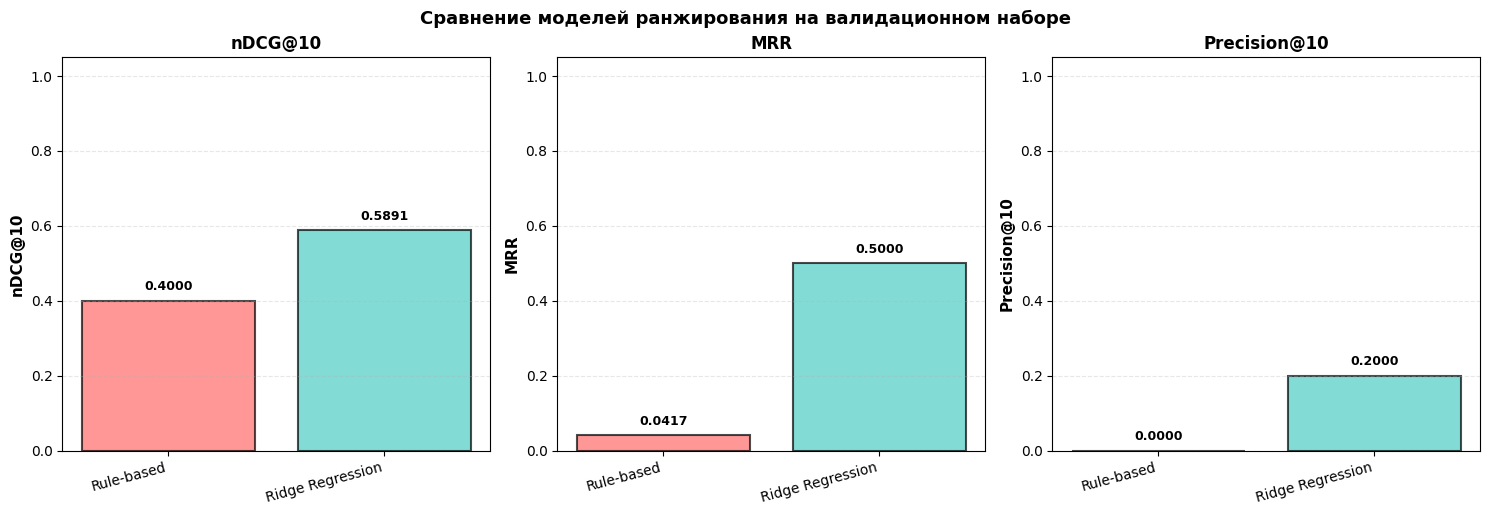

In [80]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 10

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['nDCG@10', 'MRR', 'Precision@10']
models = comparison_df['Model'].values

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metric in enumerate(metrics):
    values = comparison_df[metric].values
    ax = axes[idx]
    bars = ax.bar(models, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xticklabels(models, rotation=15, ha='right')

plt.tight_layout()
plt.suptitle('Сравнение моделей ранжирования на валидационном наборе', fontsize=13, fontweight='bold', y=1.02)
plt.show()

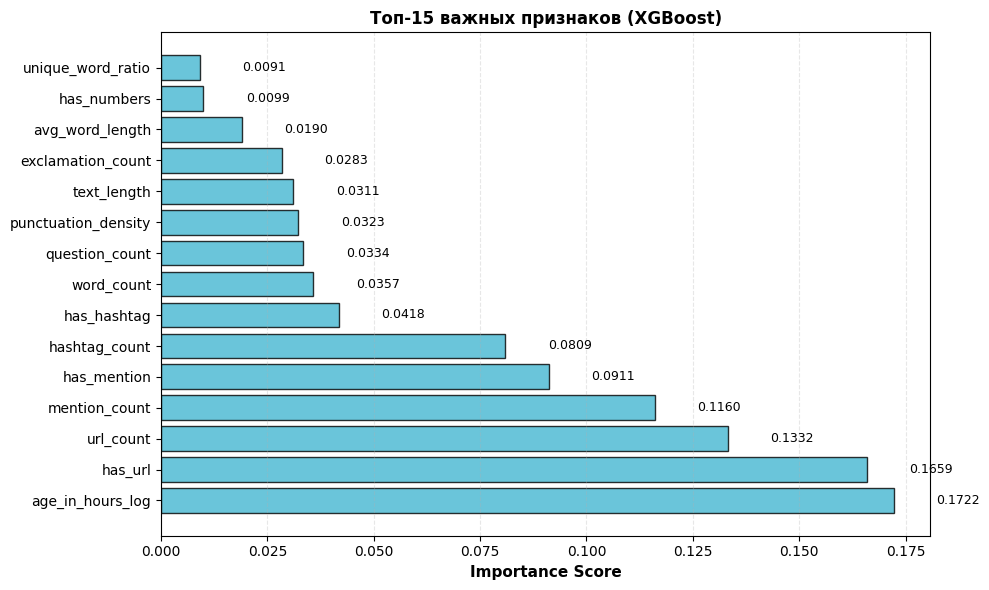

Самые значимые признаки для ранжирования:
1. age_in_hours_log          — 0.1722
2. has_url                   — 0.1659
3. url_count                 — 0.1332
4. mention_count             — 0.1160
5. has_mention               — 0.0911


In [83]:
fig, ax = plt.subplots(figsize=(10, 6))

top_n = 15
top_features = feature_importance.head(top_n)

bars = ax.barh(range(len(top_features)), top_features['Importance'].values, color='#45B7D1', alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values)
ax.set_xlabel('Importance Score', fontsize=11, fontweight='bold')
ax.set_title(f'Топ-{top_n} важных признаков (XGBoost)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

for i, (idx, row) in enumerate(top_features.iterrows()):
    ax.text(row['Importance'] + 0.01, i, f"{row['Importance']:.4f}", 
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Самые значимые признаки для ранжирования:")
for i, (idx, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"{i}. {row['Feature']:<25} — {row['Importance']:.4f}")

DL Baselines: GRU и Transformer на PyTorch

BiGRU (Bidirectional GRU):**
- Input: масштабированные признаки (14 размерность)
- BiGRU: двусторонняя GRU с 64 units
- Dense layers: 32 → 16 → 1 (предсказание ранжирующего скора)

Transformer:**
- Attention-based архитектура
- Multi-head self-attention (8 heads)
- Feed-forward network (2048 hidden units)
- 4 трансформер блока

In [86]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1).to(device)
X_val_tensor = torch.FloatTensor(X_val_scaled).to(device)
y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1, 1).to(device)

X_train_seq = X_train_tensor.unsqueeze(1)
X_val_seq = X_val_tensor.unsqueeze(1)

print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}")
print(f"Input size (number of features): {X_train_scaled.shape[1]}")

class BiGRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, dropout=0.3):
        super(BiGRUModel, self).__init__()
        self.gru1 = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(dropout)
        self.gru2 = nn.GRU(hidden_size * 2, hidden_size, batch_first=True, bidirectional=False)
        self.dropout2 = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        out, _ = self.gru1(x)
        out = self.dropout1(out)
        out, _ = self.gru2(out)
        out = self.dropout2(out[:, -1, :])
        out = self.relu(self.fc1(out))
        out = self.relu(self.fc2(out))
        out = self.fc3(out)
        return out

bigru_torch = BiGRUModel(input_size=X_train_scaled.shape[1]).to(device)
optimizer_gru = optim.Adam(bigru_torch.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("\nBiGRU Model (PyTorch):")
print(bigru_torch)

train_dataset = TensorDataset(X_train_seq, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print("\n" + "="*60)
print("Обучение BiGRU на PyTorch...")
print("="*60)

epochs = 50
best_val_loss = float('inf')
patience = 10
patience_counter = 0
gru_history = {'loss': [], 'val_loss': []}

for epoch in range(epochs):
    bigru_torch.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer_gru.zero_grad()
        y_pred = bigru_torch(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer_gru.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    bigru_torch.eval()
    with torch.no_grad():
        y_val_pred = bigru_torch(X_val_seq)
        val_loss = criterion(y_val_pred, y_val_tensor).item()
    
    gru_history['loss'].append(train_loss)
    gru_history['val_loss'].append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_gru_state = bigru_torch.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            bigru_torch.load_state_dict(best_gru_state)
            break

Device: cuda
X_train_seq shape: torch.Size([8832, 1, 15])
X_val_seq shape: torch.Size([2209, 1, 15])
Input size (number of features): 15

BiGRU Model (PyTorch):
BiGRUModel(
  (gru1): GRU(15, 64, batch_first=True, bidirectional=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (gru2): GRU(128, 64, batch_first=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)

Обучение BiGRU на PyTorch...
Epoch 10/50 | Train Loss: 0.0048 | Val Loss: 0.0060
Epoch 20/50 | Train Loss: 0.0043 | Val Loss: 0.0056
Epoch 30/50 | Train Loss: 0.0040 | Val Loss: 0.0055

Early stopping at epoch 33


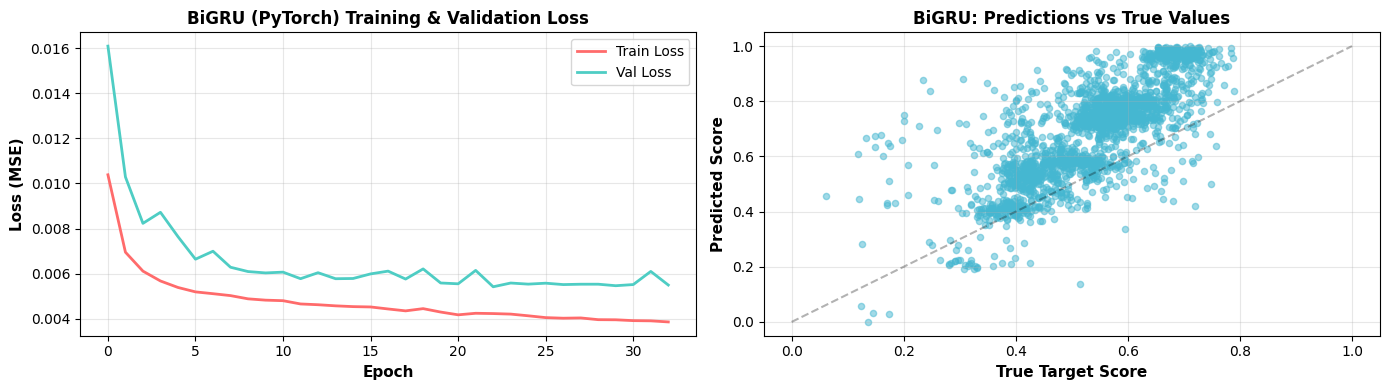

BiGRU DL BASELINE (PyTorch - Bidirectional GRU)
nDCG@10:      0.8857
MRR:          1.0000
Precision@10: 1.0000


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(gru_history['loss'], label='Train Loss', linewidth=2, color='#FF6B6B')
axes[0].plot(gru_history['val_loss'], label='Val Loss', linewidth=2, color='#4ECDC4')
axes[0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=11, fontweight='bold')
axes[0].set_title('BiGRU (PyTorch) Training & Validation Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

bigru_torch.eval()
with torch.no_grad():
    y_pred_gru_torch = bigru_torch(X_val_seq).cpu().numpy().flatten()

y_pred_gru_norm = (y_pred_gru_torch - y_pred_gru_torch.min()) / (y_pred_gru_torch.max() - y_pred_gru_torch.min() + 1e-6)

ndcg_gru = ndcg_at_k(y_val_array, y_pred_gru_norm, k=10)
mrr_gru = mrr_score(y_val_array, y_pred_gru_norm)
prec_gru = precision_at_k(y_val_array, y_pred_gru_norm, k=10)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].scatter(y_val_array, y_pred_gru_norm, alpha=0.5, color='#45B7D1', s=20)
axes[1].set_xlabel('True Target Score', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Predicted Score', fontsize=11, fontweight='bold')
axes[1].set_title('BiGRU: Predictions vs True Values', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("BiGRU DL BASELINE (PyTorch - Bidirectional GRU)")
print(f"nDCG@10:      {ndcg_gru:.4f}")
print(f"MRR:          {mrr_gru:.4f}")
print(f"Precision@10: {prec_gru:.4f}")

## Transformer Model

In [89]:
class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=8, num_layers=4, dim_ff=256, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation='relu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc1 = nn.Linear(d_model, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

transformer_model = TransformerModel(input_size=X_train_scaled.shape[1], d_model=64, nhead=8, num_layers=4).to(device)
optimizer_transformer = optim.Adam(transformer_model.parameters(), lr=0.001)

print("Transformer Model (PyTorch):")
print(transformer_model)

epochs = 50
best_val_loss = float('inf')
patience = 10
patience_counter = 0
transformer_history = {'loss': [], 'val_loss': []}

for epoch in range(epochs):
    transformer_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer_transformer.zero_grad()
        y_pred = transformer_model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer_transformer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    transformer_model.eval()
    with torch.no_grad():
        y_val_pred = transformer_model(X_val_seq)
        val_loss = criterion(y_val_pred, y_val_tensor).item()
    
    transformer_history['loss'].append(train_loss)
    transformer_history['val_loss'].append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_transformer_state = transformer_model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            transformer_model.load_state_dict(best_transformer_state)
            break

Transformer Model (PyTorch):
TransformerModel(
  (embedding): Linear(in_features=15, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (re

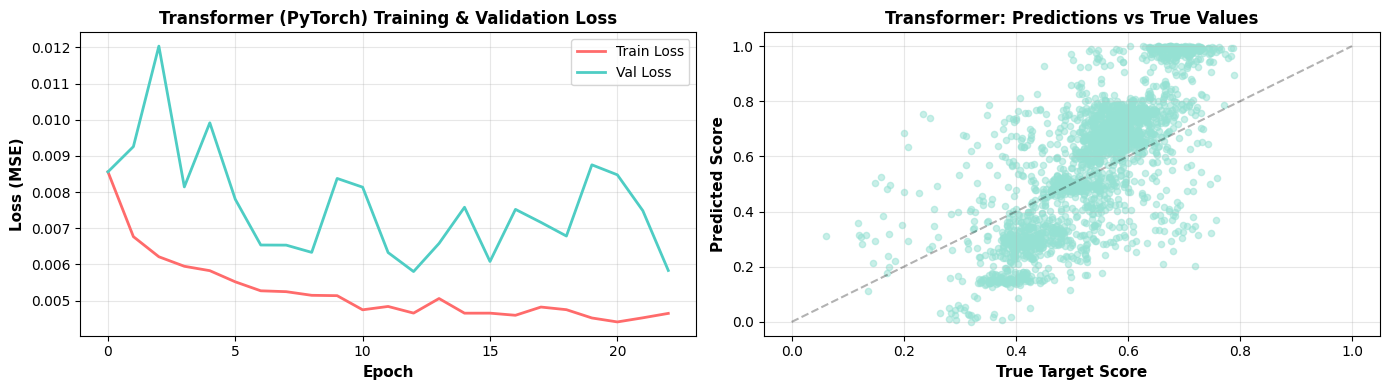

nDCG@10:      0.8461
MRR:          1.0000
Precision@10: 1.0000


In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(transformer_history['loss'], label='Train Loss', linewidth=2, color='#FF6B6B')
axes[0].plot(transformer_history['val_loss'], label='Val Loss', linewidth=2, color='#4ECDC4')
axes[0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Loss (MSE)', fontsize=11, fontweight='bold')
axes[0].set_title('Transformer (PyTorch) Training & Validation Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

transformer_model.eval()
with torch.no_grad():
    y_pred_transformer = transformer_model(X_val_seq).cpu().numpy().flatten()

y_pred_transformer_norm = (y_pred_transformer - y_pred_transformer.min()) / (y_pred_transformer.max() - y_pred_transformer.min() + 1e-6)

ndcg_transformer = ndcg_at_k(y_val_array, y_pred_transformer_norm, k=10)
mrr_transformer = mrr_score(y_val_array, y_pred_transformer_norm)
prec_transformer = precision_at_k(y_val_array, y_pred_transformer_norm, k=10)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].scatter(y_val_array, y_pred_transformer_norm, alpha=0.5, color='#95E1D3', s=20)
axes[1].set_xlabel('True Target Score', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Predicted Score', fontsize=11, fontweight='bold')
axes[1].set_title('Transformer: Predictions vs True Values', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"nDCG@10:      {ndcg_transformer:.4f}")
print(f"MRR:          {mrr_transformer:.4f}")
print(f"Precision@10: {prec_transformer:.4f}")

In [92]:
results_final = {
    'Rule-based': {'nDCG@10': ndcg_rule, 'MRR': mrr_rule, 'Precision@10': prec_rule},
    'Ridge': {'nDCG@10': ndcg_ridge, 'MRR': mrr_ridge, 'Precision@10': prec_ridge},
    'XGBoost': {'nDCG@10': ndcg_xgb, 'MRR': mrr_xgb, 'Precision@10': prec_xgb},
    'BiGRU (PyTorch)': {'nDCG@10': ndcg_gru, 'MRR': mrr_gru, 'Precision@10': prec_gru},
    'Transformer': {'nDCG@10': ndcg_transformer, 'MRR': mrr_transformer, 'Precision@10': prec_transformer},
}

final_comparison_df = pd.DataFrame(results_final).T
final_comparison_df = final_comparison_df.reset_index().rename(columns={'index': 'Model'})

print("ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ 5 МОДЕЛЕЙ (Rule-based → Ridge → XGBoost → GRU → Transformer)")
print(final_comparison_df.to_string(index=False))

best_model_name = final_comparison_df.loc[final_comparison_df['nDCG@10'].idxmax(), 'Model']
best_ndcg_final = final_comparison_df['nDCG@10'].max()

print(f"\nЛучшая модель по nDCG@10: {best_model_name} ({best_ndcg_final:.4f})")

print("\nЛучшие результаты по метрикам:")
for metric in ['nDCG@10', 'MRR', 'Precision@10']:
    best_idx = final_comparison_df[metric].idxmax()
    best_val = final_comparison_df.loc[best_idx, metric]
    best_m = final_comparison_df.loc[best_idx, 'Model']
    print(f"  - {metric}: {best_m} ({best_val:.4f})")


ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ 5 МОДЕЛЕЙ (Rule-based → Ridge → XGBoost → GRU → Transformer)
          Model  nDCG@10      MRR  Precision@10
     Rule-based 0.400035 0.041667           0.0
          Ridge 0.589093 0.500000           0.2
        XGBoost 0.870934 1.000000           1.0
BiGRU (PyTorch) 0.885709 1.000000           1.0
    Transformer 0.846080 1.000000           1.0

Лучшая модель по nDCG@10: BiGRU (PyTorch) (0.8857)

Лучшие результаты по метрикам:
  - nDCG@10: BiGRU (PyTorch) (0.8857)
  - MRR: XGBoost (1.0000)
  - Precision@10: XGBoost (1.0000)


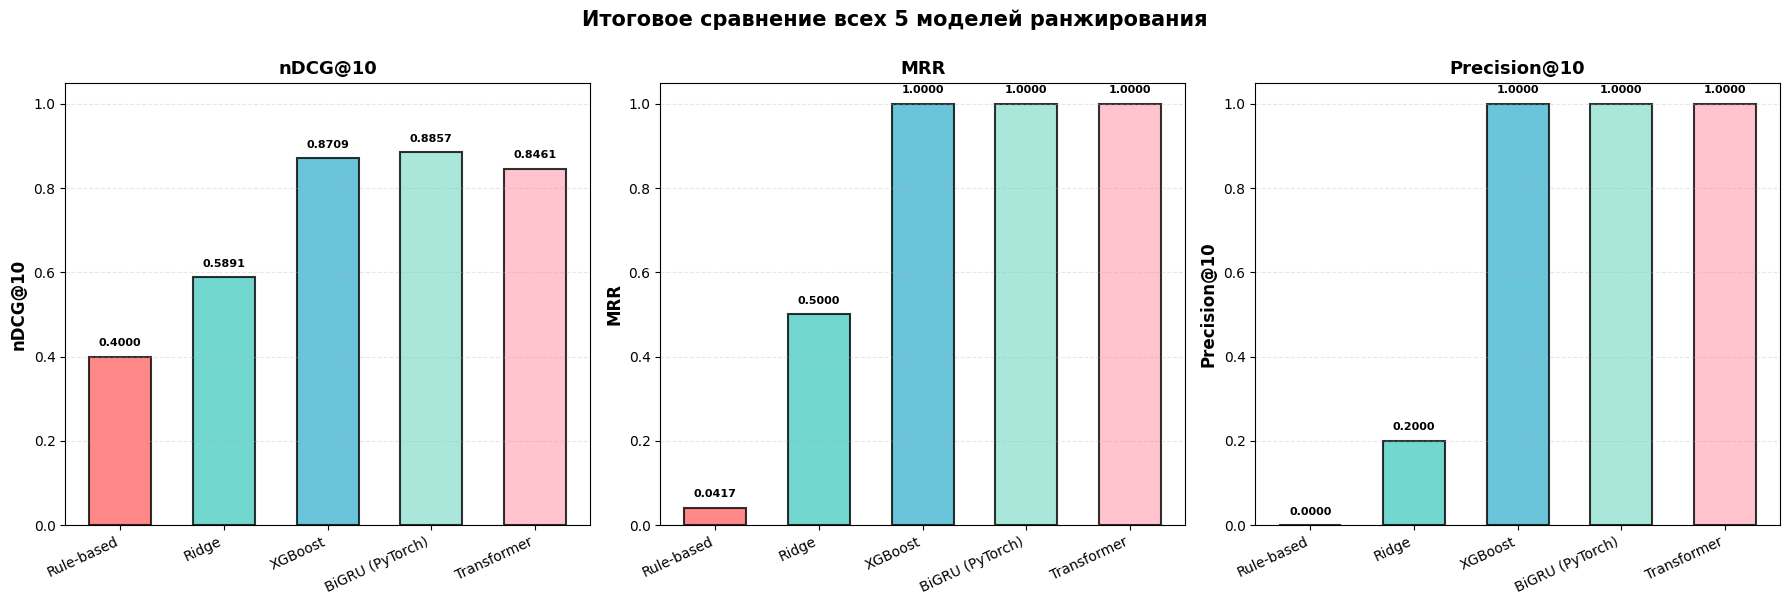

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['nDCG@10', 'MRR', 'Precision@10']
models = final_comparison_df['Model'].values
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#FFB6C1']

x = np.arange(len(models))
width = 0.6

for idx, metric in enumerate(metrics):
    values = final_comparison_df[metric].values
    ax = axes[idx]
    
    bars = ax.bar(x, values, width=width, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10)
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Итоговое сравнение всех 5 моделей ранжирования', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

лушая модель - xgboost, в целом можно использовать перед выдачей постов пользователю в формате Сбор постов → Классификация → ранжирование → .. → Выдача